# 第 1 章：机器学习术语与 AI 辅助编程

本 notebook 配合课件《机器学习导论：学习范式与 AI 辅助编程》使用，共四个部分：

1. **环境核对**：确认 Python 与 scikit-learn 版本；
2. **术语与预测**：用 8 行 Auto MPG 子集指认术语，并观察模型在训练数据与测试数据上的误差；
3. **训练与拟合**：用时刻预测工作日共享单车需求，观察欠拟合、适当拟合和过拟合；
4. **AI 辅助编程实操**：把同一个预测任务交给 AI 编程工具完成。

约定：本 notebook 为课堂新建版本，**不带预存输出**，所有代码课上现场运行；课件中引用的数字以你屏幕上的实际输出为准。

## 1. 环境核对

运行下面的代码，记录 Python 和 scikit-learn 版本。

In [1]:
import sys
import sklearn

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)

Python: 3.14.6
scikit-learn: 1.9.0


课件全部输出基于 **Python 3.14.6、scikit-learn 1.9.0**。复现实验结果时，请同时记录软件版本。

## 2. 用汽车数据认识基本术语

UCI **Auto MPG**（1970–1982 实测）子集，与课件“基本术语”一页一致：

| 车型 | 马力 | 车重(lb) | mpg |
|---|---|---|---|
| datsun 1200 | 69 | 1613 | 35.0 |
| toyota corona | 52 | 1649 | 31.0 |
| toyota starlet | 58 | 1755 | 39.1 |
| honda civic 1300 | 60 | 1760 | 35.1 |
| toyota corolla 1200 | 65 | 1773 | 31.0 |
| honda civic | 53 | 1795 | 33.0 |
| honda civic cvcc | 53 | 1795 | 33.0 |
| honda civic 1500 gl | 67 | 1850 | 44.6 |

选取规则：按车重升序，第 1–6 行为训练数据，第 7–8 行为测试数据（未参与训练）。

对照课件逐个指认（先自己答，再往下看括号）：

- 一行对应什么？（一个**样本**，样本数 n=8）
- 哪两列是**特征**？（马力、车重，特征数 d=2）
- 哪一列是**标签**？（mpg，每加仑行驶英里数）
- 只用前 6 辆车估计参数，这 6 行叫什么？（**训练集**）
- “mpg ≈ 19.3 + 0.09×马力 + 0.006×车重”里，19.3、0.09、0.006 叫什么？（**参数**；整条规则是**模型**）
- 第 7、8 辆车是**测试样本**：用来观察模型在没见过的数据上的**泛化**表现

In [2]:
# 把上表写成 Python 变量（课上现场运行）
horsepower = [69, 52, 58, 60, 65, 53, 53, 67]              # 马力（列 2）
weight = [1613, 1649, 1755, 1760, 1773, 1795, 1795, 1850]  # 车重 lb（列 3）
mpg = [35.0, 31.0, 39.1, 35.1, 31.0, 33.0, 33.0, 44.6]      # mpg（列 4）

print(f"第 1 个样本：马力={horsepower[0]}，车重={weight[0]}，mpg={mpg[0]}")
print("特征：马力、车重；特征数 d = 2")
print("标签：mpg")
print("样本数 n =", len(mpg))
print("训练集样本数 =", len(mpg[:6]))

第 1 个样本：马力=69，车重=1613，mpg=35.0
特征：马力、车重；特征数 d = 2
标签：mpg
样本数 n = 8
训练集样本数 = 6


### 2.1 用课件中的模型做一次预测

课件给出了一个已经用前 6 行数据确定参数的模型：

**预测 mpg = 19.3 + 0.09 × 马力 + 0.006 × 车重**

本节直接使用这组参数，观察模型怎样根据特征得到预测。

In [3]:
row = 0
prediction = 19.3 + 0.09 * horsepower[row] + 0.006 * weight[row]
error = abs(prediction - mpg[row])

print(f"预测 mpg：{prediction:.2f}")
print(f"真实 mpg：{mpg[row]:.2f}")
print(f"绝对误差：{error:.2f}")

预测 mpg：35.19
真实 mpg：35.00
绝对误差：0.19


把同一个模型依次用于 8 辆车。前 6 行是训练数据，后 2 行是测试数据。先运行下一格，再比较每行误差。

In [4]:
predictions = []
errors = []
for hp, wt, actual in zip(horsepower, weight, mpg):
    prediction = 19.3 + 0.09 * hp + 0.006 * wt
    predictions.append(prediction)
    errors.append(abs(prediction - actual))

for row, (prediction, error) in enumerate(zip(predictions, errors), start=1):
    use = "训练" if row <= 6 else "测试"
    print(f"第 {row} 行（{use}）：预测 {prediction:.2f}，误差 {error:.2f}")

第 1 行（训练）：预测 35.19，误差 0.19
第 2 行（训练）：预测 33.87，误差 2.87
第 3 行（训练）：预测 35.05，误差 4.05
第 4 行（训练）：预测 35.26，误差 0.16
第 5 行（训练）：预测 35.79，误差 4.79
第 6 行（训练）：预测 34.84，误差 1.84
第 7 行（测试）：预测 34.84，误差 1.84
第 8 行（测试）：预测 36.43，误差 8.17


这里共有 6 个训练样本和 2 个测试样本。样本很少，本节只用它说明泛化的含义。

In [11]:
train_error = sum(errors[:6]) / len(errors[:6])
test_error = sum(errors[6:]) / len(errors[6:])

print(f"训练数据平均绝对误差：{train_error:.2f} mpg")
print(f"测试数据平均绝对误差：{test_error:.2f} mpg")

训练数据平均绝对误差：2.32 mpg
测试数据平均绝对误差：5.01 mpg


**检查题：** 测试数据的平均误差明显大于训练数据的平均误差。只看训练误差，能判断模型在新数据上的表现吗？为什么？

<details><summary>参考答案</summary>

不能。训练误差只反映模型对参与训练的数据拟合得怎样。模型在未参与训练的数据上可能出现更大的误差，因此还要检查测试数据上的表现。这就是泛化。

</details>

## 3. 第一次训练模型：时刻与共享单车需求

下面使用一天中的时刻预测工作日平均共享单车租赁量。原始记录来自 UCI 的 [Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)，也可在 [Kaggle 镜像](https://www.kaggle.com/datasets/sriramm2010/uci-bike-sharing-data)查看；许可证为 CC BY 4.0，核查日期为 2026-09-14。这里将 2011—2012 年的工作日记录按小时求平均，得到 24 行数据，并直接写入下一格。

这里只使用“时刻”一个特征，目的是看清模型复杂度的影响，不用于建立完整的需求预测系统。

In [12]:
# 数据内置在 notebook 中，展开本格可以查看
import pandas as pd

#      阶段                       数据结构
# 读数据、清洗、特征工程	      DataFrame
# 传给 sklearn 训练	          DataFrame 或 ndarray 均可
# 传给 PyTorch / TensorFlow	  Tensor（需先转 numpy）

bike_data = pd.DataFrame({
    "hour": list(range(24)),
    "rentals": [36.8, 16.6, 8.7, 4.9, 5.4, 24.9, 102.5, 290.6, 477.0, 241.5, 135.4, 158.2, 200.8, 198.4, 183.6, 201.3, 293.1, 525.3, 492.2, 348.4, 249.7, 186.3, 138.4, 88.7],
})
print("数据形状：", bike_data.shape)
bike_data.head()

数据形状： (24, 2)


,hour,rentals
0,0,36.8
1,1,16.6
2,2,8.7
3,3,4.9
4,4,5.4


### 3.1 划分训练数据和测试数据

时刻是特征，平均租赁量是标签。每隔 4 小时保留一个时刻作为测试数据，使测试点均匀分布在一天中。

In [13]:
hour = bike_data[["hour"]]
rentals = bike_data["rentals"]
is_test = bike_data["hour"] % 4 == 1
hour_train, hour_test = hour[~is_test], hour[is_test]
rentals_train, rentals_test = rentals[~is_test], rentals[is_test]
print("训练样本数：", len(hour_train))
print("测试样本数：", len(hour_test))

训练样本数： 18
测试样本数： 6


### 3.2 训练模型并给出预测

先训练一个 7 次多项式回归模型。`fit()` 使用训练数据估计参数，`predict()` 使用已经确定的参数预测租赁量；测试数据不参与训练。

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = make_pipeline(
    PolynomialFeatures(7, include_bias=False), StandardScaler(), LinearRegression()
)
model.fit(hour_train, rentals_train)
rentals_prediction = model.predict(hour_test)

prediction_table = hour_test.copy()
prediction_table["实际租赁量"] = rentals_test
prediction_table["预测租赁量"] = rentals_prediction.round(1)
prediction_table.sort_values("hour")

,hour,实际租赁量,预测租赁量
1,1,16.6,19.0
5,5,24.9,118.9
9,9,241.5,286.6
13,13,198.4,148.9
17,17,525.3,361.7
21,21,186.3,182.4


### 3.3 比较三种拟合状态

下面三个模型使用相同的数据、训练方法和回归模型，只改变多项式的次数。次数越高，曲线可以弯折得越多。先比较训练误差和测试误差，再看拟合曲线。

In [22]:
degrees = {
    "欠拟合：1 次多项式": 1,
    "适当拟合：7 次多项式": 7,
    "过拟合：15 次多项式": 15,
}
models = {
    name: make_pipeline(
        PolynomialFeatures(degree, include_bias=False), StandardScaler(), LinearRegression()
    )
    for name, degree in degrees.items()
}

In [23]:
model_results = {}
for name, model in models.items():
    model.fit(hour_train, rentals_train)
    train_error = mean_absolute_error(rentals_train, model.predict(hour_train))
    test_error = mean_absolute_error(rentals_test, model.predict(hour_test))
    model_results[name] = model, train_error, test_error
    print(f"{name}：训练误差 {train_error:.0f}，测试误差 {test_error:.0f}")

欠拟合：1 次多项式：训练误差 97，测试误差 106
适当拟合：7 次多项式：训练误差 52，测试误差 60
过拟合：15 次多项式：训练误差 40，测试误差 86


三幅图使用相同的坐标范围。蓝点是训练数据，橙点是测试数据，曲线是模型对一天中不同时刻的预测。

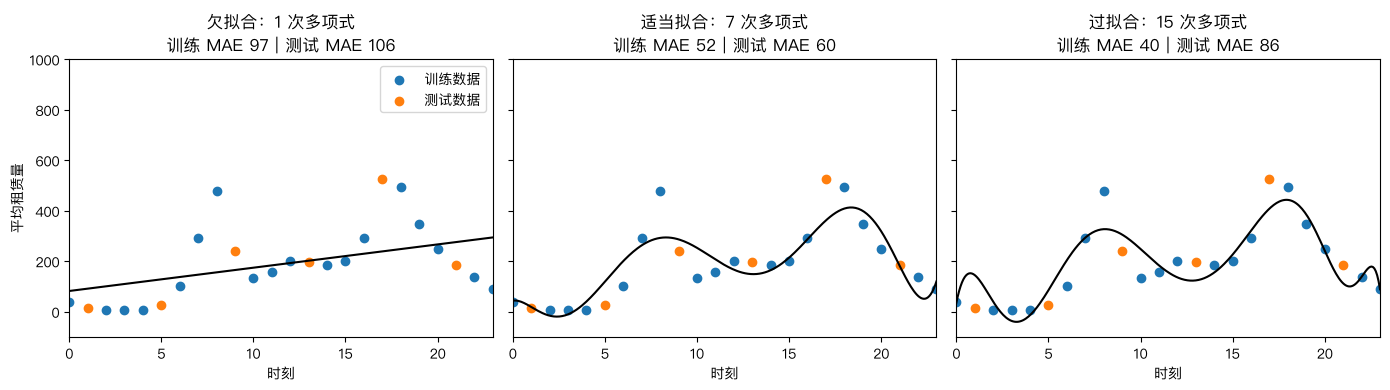

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "PingFang SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

grid = pd.DataFrame({"hour": np.linspace(0, 23, 300)})
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, (name, (model, train_error, test_error)) in zip(axes, model_results.items()):
    ax.scatter(hour_train, rentals_train, label="训练数据")
    ax.scatter(hour_test, rentals_test, label="测试数据")
    ax.plot(grid["hour"], model.predict(grid), color="black")
    ax.set_title(f"{name}\n训练 MAE {train_error:.0f}｜测试 MAE {test_error:.0f}")
    ax.set_xlabel("时刻")
    ax.set_xlim(0, 23)
    ax.set_ylim(-100, 1000)
axes[0].set_ylabel("平均租赁量")
axes[0].legend()
plt.tight_layout()
plt.show()

<details><summary>怎样判断三种状态？</summary>

1 次曲线只能表示直线，无法表现工作日早晚两个高峰，训练误差和测试误差都较大，属于欠拟合。7 次曲线表现了需求随时刻变化的主要趋势，测试误差也较小，在本例中拟合程度较合适。15 次曲线几乎穿过所有训练数据，训练误差很小，但曲线出现不合理的剧烈弯折，测试误差随之增大，属于过拟合。

</details>

## 4. AI 辅助编程（Vibe Coding）实操

打开课堂指定的 Web Coding 工具，选择“执行”或 Build 模式。

| 步骤 | 要做的事 |
|---|---|
| ① 提需求 | 复制下面的提示词；需要时再加上第二张表中的可选要求 |
| ② 审代码 | 看清数据、`fit()`、`predict()` 和误差分别写在哪里 |
| ③ 跑通 | 让工具执行全部单元格，出现报错就继续让它修改 |
| ④ 核对结果 | 确认三个模型都有训练误差和测试误差 |

直接复制：

> 请读取当前 notebook 第三节中的共享单车数据，另建一个 notebook 完成同样的预测任务。用时刻预测工作日平均租赁量，分别训练 1 次、7 次和 15 次多项式回归，三个模型只改变多项式次数。沿用第三节的训练、测试划分，打印每个模型的训练误差和测试误差。请直接编写并运行代码，数据写在 notebook 中，不要另外下载文件。

| 想增加的功能 | 追加到提示词末尾 |
|---|---|
| 看拟合曲线 | 把三种模型画成并排的三幅图，同时显示数据点和拟合曲线。 |
| 自己输入时刻 | 使用 7 次模型，让我输入 0 到 23 的时刻并得到预测租赁量。 |